In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding,Dense,GlobalAveragePooling1D,Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [13]:
df = pd.read_csv("C:\XPrathmesh\College Stuff\DeepLearning\IMDB Dataset.csv", encoding='latin1')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [14]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [15]:
texts = df['review'].values
labels = LabelEncoder().fit_transform(df['sentiment'].values)

In [16]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences,maxlen=200)

In [17]:
x_train,x_test,y_train,y_test = train_test_split(padded,labels,random_state=42,test_size=0.2)

In [55]:
model = Sequential([
    Embedding(input_dim=10000,output_dim=16,input_length=200),
    GlobalAveragePooling1D(),
    Dense(16,activation='relu'),
    Dropout(0.2),
    Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss="binary_crossentropy",metrics=['Accuracy'])

In [56]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_6           │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
history = model.fit(x_train,y_train,epochs=20,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - Accuracy: 0.6907 - loss: 0.5842 - val_Accuracy: 0.8802 - val_loss: 0.2974
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Accuracy: 0.8815 - loss: 0.2946 - val_Accuracy: 0.8900 - val_loss: 0.2658
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Accuracy: 0.9047 - loss: 0.2459 - val_Accuracy: 0.8871 - val_loss: 0.2686
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Accuracy: 0.9197 - loss: 0.2192 - val_Accuracy: 0.8877 - val_loss: 0.2663
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Accuracy: 0.9282 - loss: 0.2001 - val_Accuracy: 0.8905 - val_loss: 0.2690
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Accuracy: 0.9367 - loss: 0.1843 - val_Accuracy: 0.8890 - val_loss: 0.2767
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Accuracy: 0.9393 - loss: 0.1776 - val_Accuracy: 0.8872 - val_loss: 0.2841
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Accuracy: 0.9485 - loss: 0.1574 - 

In [58]:
loss,accuracy = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - Accuracy: 0.8662 - loss: 0.4987


In [62]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (32, 200, 16)               │         160,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_6           │ (32, 16)                    │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (32, 16)                    │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (32, 16)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (32, 1)                     │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 480,869 (1.83 MB)

 Trainable params: 160,289 (626.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 320,580 (1.22 MB)

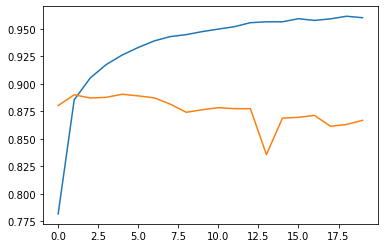

In [59]:
plt.plot(history.history["Accuracy"], label="Accuracy")
plt.plot(history.history["val_Accuracy"], label="Val Accuracy")
plt.show()

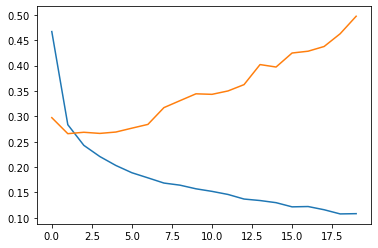

In [60]:
plt.plot(history.history["loss"],label="Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dense,Dropout,GlobalAveragePooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("C:\XPrathmesh\College Stuff\DeepLearning\IMDB Dataset.csv",encoding='latin1')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [6]:
df.info

<bound method DataFrame.info of                                                   review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
49995  I thought this movie did a down right good job...  positive
49996  Bad plot, bad dialogue, bad acting, idiotic di...  negative
49997  I am a Catholic taught in parochial elementary...  negative
49998  I'm going to have to disagree with the previou...  negative
49999  No one expects the Star Trek movies to be high...  negative

[50000 rows x 2 columns]>

In [7]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
texts = df["review"].values
labels = LabelEncoder().fit_transform(df["sentiment"].values)

In [13]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequence = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequence,maxlen=200)

In [14]:
x_train,x_test,y_train,y_test = train_test_split(padded,labels,random_state=42,test_size=0.2)

In [15]:
model = Sequential([
    Embedding(input_dim=10000,output_dim=16,input_length=200),
    GlobalAveragePooling1D(),
    Dense(16,activation='relu'),
    Dropout(0.2),
    Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=["Accuracy"])

C:\Users\kprat\anaconda3\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
early_Stopping = EarlyStopping(monitor='val_loss',patience=2, restore_best_weights=True)
history = model.fit(x_train,y_train,epochs=20,batch_size=32,validation_data=(x_test,y_test),callbacks=[early_Stopping])

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - Accuracy: 0.6890 - loss: 0.5816 - val_Accuracy: 0.8573 - val_loss: 0.3264
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Accuracy: 0.8791 - loss: 0.2946 - val_Accuracy: 0.8828 - val_loss: 0.2767
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Accuracy: 0.9043 - loss: 0.2493 - val_Accuracy: 0.8877 - val_loss: 0.2644
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Accuracy: 0.9145 - loss: 0.2264 - val_Accuracy: 0.8852 - val_loss: 0.2753
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - Accuracy: 0.9282 - loss: 0.1961 - val_Accuracy: 0.8895 - val_loss: 0.2690


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (32, 200, 16)               │         160,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (32, 16)                    │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 16)                    │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (32, 16)                    │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 1)                     │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 480,869 (1.83 MB)

 Trainable params: 160,289 (626.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 320,580 (1.22 MB)

In [21]:
loss,accuracy = model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - Accuracy: 0.8850 - loss: 0.2669


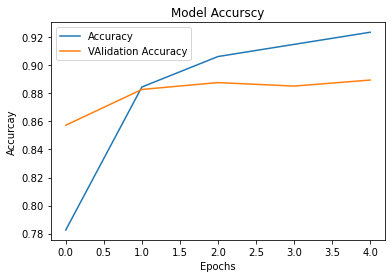

In [30]:
plt.plot(history.history['Accuracy'],label="Accuracy")
plt.plot(history.history['val_Accuracy'],label="VAlidation Accuracy")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accurcay")
plt.title("Model Accurscy")
plt.show()

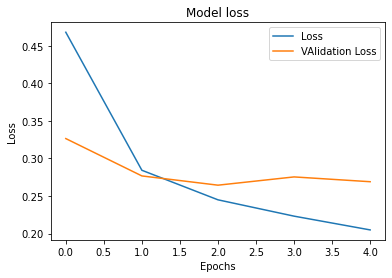

In [31]:
plt.plot(history.history['loss'],label="Loss")
plt.plot(history.history['val_loss'],label="VAlidation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model loss")
plt.legend()
plt.show()